In [2]:
import os

print(os.listdir("/content"))

['.config', 'PowerBI_Tutorial_Matching_Sales_Dataset.xlsx', 'sample_data']


In [3]:
#Load the Excel file
import pandas as pd

file_path = "/content/PowerBI_Tutorial_Matching_Sales_Dataset.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Sales_Data', 'Customers', 'Products', 'Date_Table']


In [4]:
#Load the Sales_Data sheet
sales_df = pd.read_excel(
    "/content/PowerBI_Tutorial_Matching_Sales_Dataset.xlsx",
    sheet_name="Sales_Data"
)

print("Dataset loaded successfully!")
print("Rows:", sales_df.shape[0])
print("Columns:", sales_df.shape[1])

sales_df.head()


Dataset loaded successfully!
Rows: 800
Columns: 19


,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Region,Product_ID,Product,Category,Quantity,Unit_Price,Discount_%,Sales,Cost,Profit,Year,Month,Month_Number,Quarter
0,ORD10098,2024-01-01,C014,Neha Joshi,Surat,West,P009,Webcam,Accessories,3,3377.10,5,9624.73,6158.77,3465.96,2024,Jan,1,Q1
1,ORD10380,2024-01-01,C010,Sneha Rao,Visakhapatnam,South,P008,Headphones,Accessories,2,2639.20,0,5278.40,3967.59,1310.81,2024,Jan,1,Q1
2,ORD10185,2024-01-02,C014,Neha Joshi,Surat,West,P004,Monitor,Electronics,1,14732.63,10,13259.37,9153.31,4106.06,2024,Jan,1,Q1
3,ORD10546,2024-01-02,C015,Sanjay Yadav,Patna,East,P010,Office Chair,Furniture,4,7880.42,0,31521.68,20448.72,11072.96,2024,Jan,1,Q1
4,ORD10311,2024-01-03,C011,Rahul Das,Kolkata,East,P002,Smartphone,Electronics,1,29451.96,10,26506.76,20523.80,5982.96,2024,Jan,1,Q1


In [5]:
#Check the dataset structure
print("Column Names:")
print(sales_df.columns.tolist())

print("\nData Types:")
print(sales_df.dtypes)

print("\nMissing Values:")
print(sales_df.isnull().sum())

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'City', 'Region', 'Product_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount_%', 'Sales', 'Cost', 'Profit', 'Year', 'Month', 'Month_Number', 'Quarter']

Data Types:
Order_ID                 object
Order_Date       datetime64[ns]
Customer_ID              object
Customer_Name            object
City                     object
Region                   object
Product_ID               object
Product                  object
Category                 object
Quantity                  int64
Unit_Price              float64
Discount_%                int64
Sales                   float64
Cost                    float64
Profit                  float64
Year                      int64
Month                    object
Month_Number              int64
Quarter                  object
dtype: object

Missing Values:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
City             0
Region        

In [6]:
#Convert Order_Date to date format
sales_df["Order_Date"] = pd.to_datetime(sales_df["Order_Date"])

print("Order_Date converted successfully!")
print(sales_df["Order_Date"].dtype)

Order_Date converted successfully!
datetime64[ns]


In [7]:
#Check the date range
print("Minimum Date:", sales_df["Order_Date"].min())
print("Maximum Date:", sales_df["Order_Date"].max())

Minimum Date: 2024-01-01 00:00:00
Maximum Date: 2024-12-31 00:00:00


In [8]:
print("Duplicate rows:", sales_df.duplicated().sum())
print("Duplicate Order IDs:", sales_df["Order_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Order IDs: 0


In [9]:
#Create Monthly Sales Data
monthly_sales = (
    sales_df
    .groupby(["Year", "Month_Number", "Month"])["Sales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month_Number"])
)

monthly_sales

,Year,Month_Number,Month,Sales
0,2024,1,Jan,2525637.52
1,2024,2,Feb,1136804.35
2,2024,3,Mar,2167564.10
3,2024,4,Apr,1551041.10
4,2024,5,May,2575294.73
5,2024,6,Jun,1419783.97
6,2024,7,Jul,2882682.20
7,2024,8,Aug,1594194.86
8,2024,9,Sep,2686823.42
9,2024,10,Oct,1160037.00


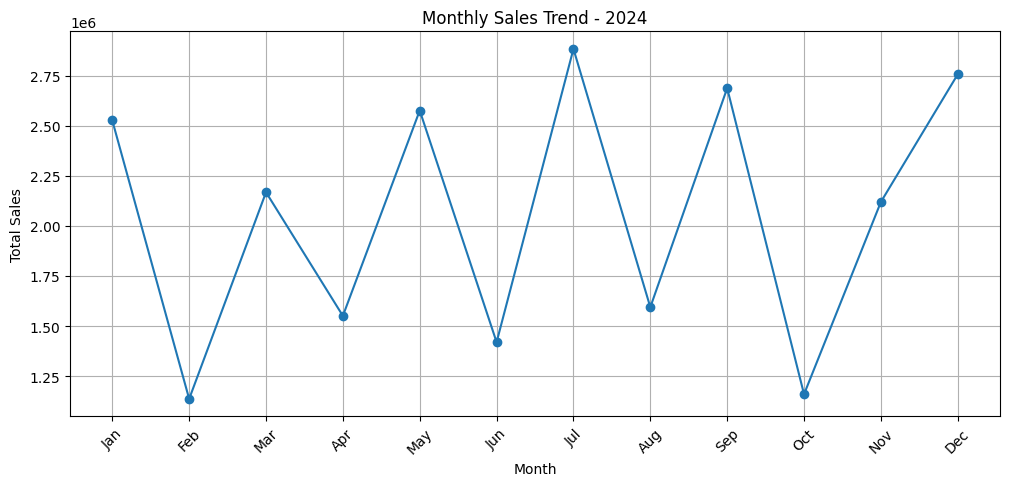

In [10]:
#creating the first visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend - 2024")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [12]:
#Prepare the time-series data

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month_Number"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Date").reset_index(drop=True)

monthly_sales[["Date", "Sales"]]

,Date,Sales
0,2024-01-01,2525637.52
1,2024-02-01,1136804.35
2,2024-03-01,2167564.10
3,2024-04-01,1551041.10
4,2024-05-01,2575294.73
5,2024-06-01,1419783.97
6,2024-07-01,2882682.20
7,2024-08-01,1594194.86
8,2024-09-01,2686823.42
9,2024-10-01,1160037.00


In [13]:
#Split the data into Training and Testing

# Create a time index for the model
monthly_sales["Time_Index"] = range(len(monthly_sales))

# Split into training and testing data
train = monthly_sales.iloc[:9].copy()
test = monthly_sales.iloc[9:].copy()

print("Training data:")
print(train[["Date", "Sales"]])

print("\nTesting data:")
print(test[["Date", "Sales"]])

Training data:
        Date       Sales
0 2024-01-01  2525637.52
1 2024-02-01  1136804.35
2 2024-03-01  2167564.10
3 2024-04-01  1551041.10
4 2024-05-01  2575294.73
5 2024-06-01  1419783.97
6 2024-07-01  2882682.20
7 2024-08-01  1594194.86
8 2024-09-01  2686823.42

Testing data:
         Date       Sales
9  2024-10-01  1160037.00
10 2024-11-01  2119322.64
11 2024-12-01  2756004.07


In [14]:
#Build the Regression Model

from sklearn.linear_model import LinearRegression

# Prepare training data
X_train = train[["Time_Index"]]
y_train = train["Sales"]

# Prepare testing data
X_test = test[["Time_Index"]]
y_test = test["Sales"]

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
test["Predicted_Sales"] = model.predict(X_test)

print("Model trained successfully!")
print("\nActual vs Predicted Sales:")
print(test[["Date", "Sales", "Predicted_Sales"]])

Model trained successfully!

Actual vs Predicted Sales:
         Date       Sales  Predicted_Sales
9  2024-10-01  1160037.00     2.336305e+06
10 2024-11-01  2119322.64     2.391570e+06
11 2024-12-01  2756004.07     2.446835e+06


In [15]:
#Evaluate the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, test["Predicted_Sales"])
rmse = np.sqrt(mean_squared_error(y_test, test["Predicted_Sales"]))
r2 = r2_score(y_test, test["Predicted_Sales"])

print("Model Evaluation Results")
print("------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------
MAE  : 585,894.91
RMSE : 719,562.62
R² Score: -0.2033


In [16]:
#Get R² Score

r2 = r2_score(y_test, test["Predicted_Sales"])

print(f"R² Score: {r2:.4f}")

R² Score: -0.2033


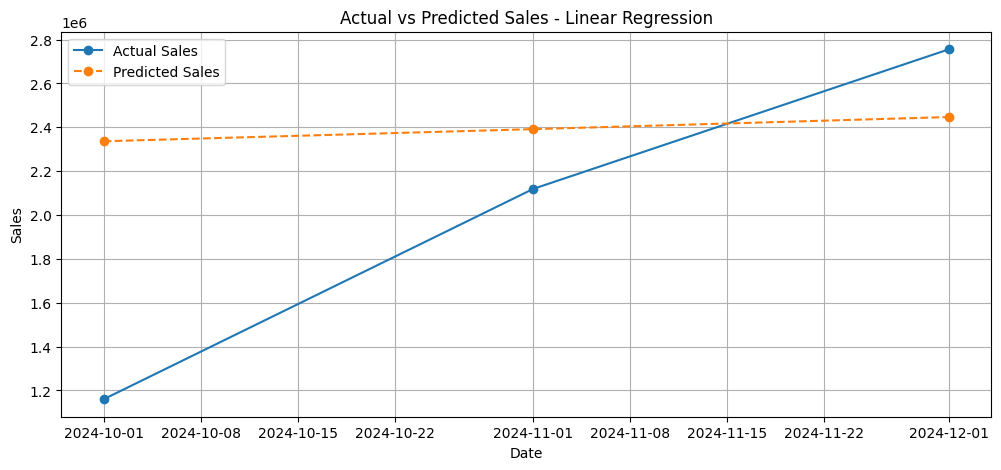

In [17]:
#Trying for a better forecasting approach

plt.figure(figsize=(12, 5))

plt.plot(
    test["Date"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    test["Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales - Linear Regression")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
#Improve the model

from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict the test data
test["RF_Predicted_Sales"] = rf_model.predict(X_test)

print("Random Forest model trained successfully!")
print("\nActual vs Random Forest Predicted Sales:")
print(test[["Date", "Sales", "RF_Predicted_Sales"]])

Random Forest model trained successfully!

Actual vs Random Forest Predicted Sales:
         Date       Sales  RF_Predicted_Sales
9  2024-10-01  1160037.00        2.478520e+06
10 2024-11-01  2119322.64        2.478520e+06
11 2024-12-01  2756004.07        2.478520e+06


In [19]:
import statsmodels.api as sm

print("Statsmodels is ready!")

Statsmodels is ready!


In [21]:
#Building the ARIMA model

from statsmodels.tsa.arima.model import ARIMA

# Prepare the training sales data as a time series
train_sales = train["Sales"].values

# Build the ARIMA model
arima_model = ARIMA(train_sales, order=(1, 0, 0))

# Train the model
arima_result = arima_model.fit()

# Forecast the next 3 months
arima_forecast = arima_result.forecast(steps=3)

# Store predictions
test["ARIMA_Predicted_Sales"] = arima_forecast

print("ARIMA model trained successfully!")
print("\nActual vs ARIMA Predicted Sales:")
print(test[["Date", "Sales", "ARIMA_Predicted_Sales"]])

ARIMA model trained successfully!

Actual vs ARIMA Predicted Sales:
         Date       Sales  ARIMA_Predicted_Sales
9  2024-10-01  1160037.00           1.571924e+06
10 2024-11-01  2119322.64           2.439979e+06
11 2024-12-01  2756004.07           1.764116e+06


In [22]:
#Evaluate ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

arima_mae = mean_absolute_error(
    test["Sales"],
    test["ARIMA_Predicted_Sales"]
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        test["ARIMA_Predicted_Sales"]
    )
)

arima_r2 = r2_score(
    test["Sales"],
    test["ARIMA_Predicted_Sales"]
)

print("ARIMA Model Evaluation")
print("----------------------")
print(f"MAE      : {arima_mae:,.2f}")
print(f"RMSE     : {arima_rmse:,.2f}")
print(f"R² Score : {arima_r2:.4f}")

ARIMA Model Evaluation
----------------------
MAE      : 574,810.32
RMSE     : 647,125.05
R² Score : 0.0268


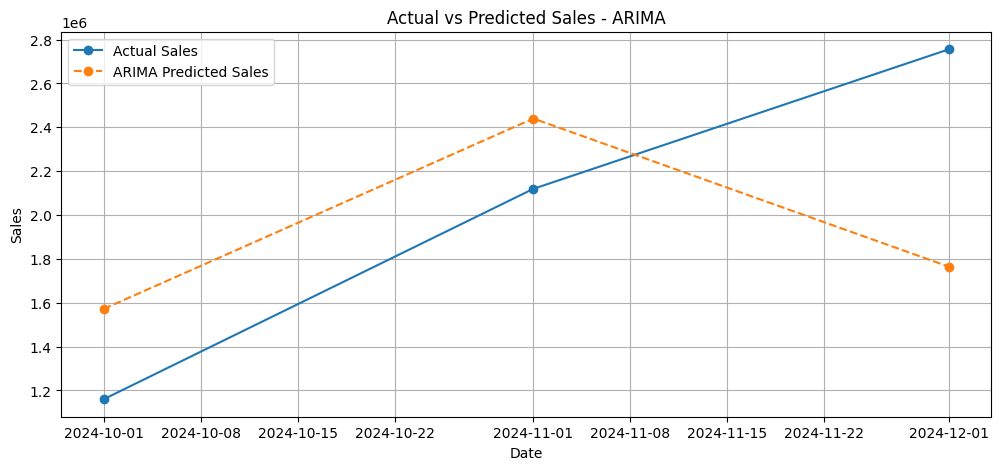

In [24]:
#ARIMA Actual vs Predicted Chart

plt.figure(figsize=(12, 5))

plt.plot(
    test["Date"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    test["ARIMA_Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="ARIMA Predicted Sales"
)

plt.title("Actual vs Predicted Sales - ARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
#Forecast Future Sales

# Use all 12 months of historical sales
full_sales = monthly_sales["Sales"].values

# Train the final ARIMA model on all historical data
final_arima = ARIMA(full_sales, order=(1, 0, 0))
final_result = final_arima.fit()

# Forecast the next 6 months
future_forecast = final_result.forecast(steps=6)

# Create future dates
future_dates = pd.date_range(
    start="2025-01-01",
    periods=6,
    freq="MS"
)

# Create forecast table
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Sales": future_forecast
})

print("Future Sales Forecast")
print("---------------------")
print(forecast_df)

Future Sales Forecast
---------------------
        Date  Forecasted_Sales
0 2025-01-01      1.554306e+06
1 2025-02-01      2.392061e+06
2 2025-03-01      1.808026e+06
3 2025-04-01      2.215182e+06
4 2025-05-01      1.931336e+06
5 2025-06-01      2.129217e+06


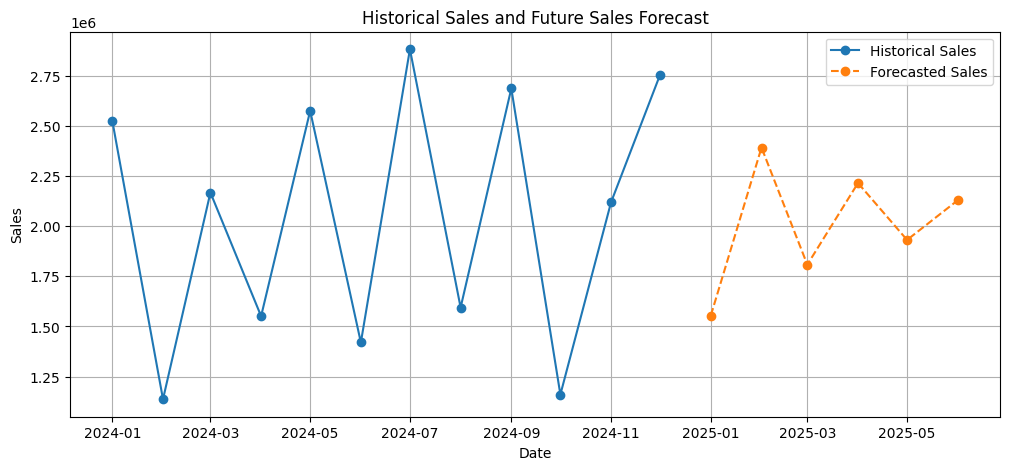

In [26]:
#Future Sales Forecast Chart

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
#saving your forecast results

forecast_df.to_csv(
    "future_sales_forecast.csv",
    index=False
)

test.to_csv(
    "model_predictions.csv",
    index=False
)

print("Forecast and prediction files saved successfully!")

Forecast and prediction files saved successfully!


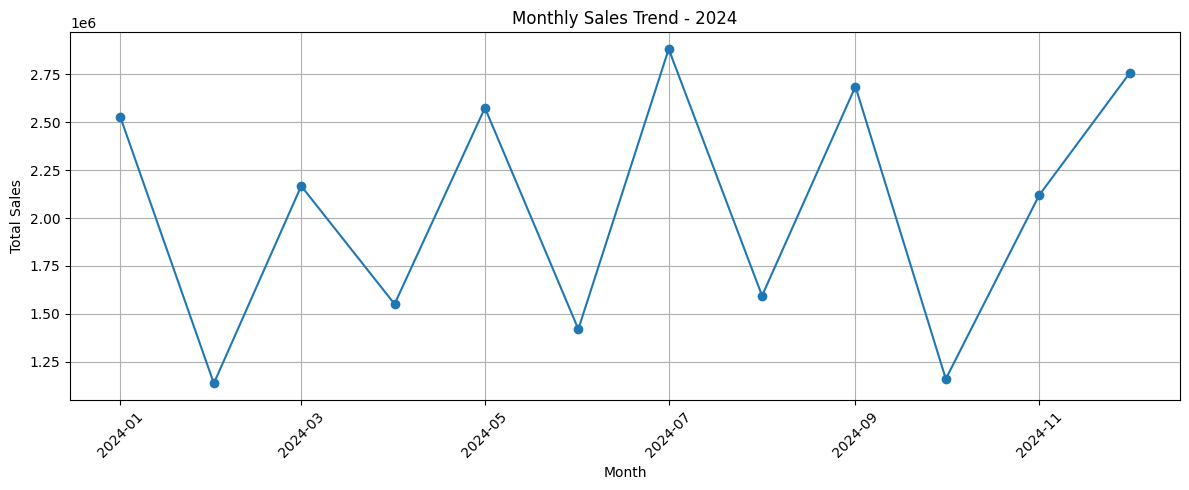

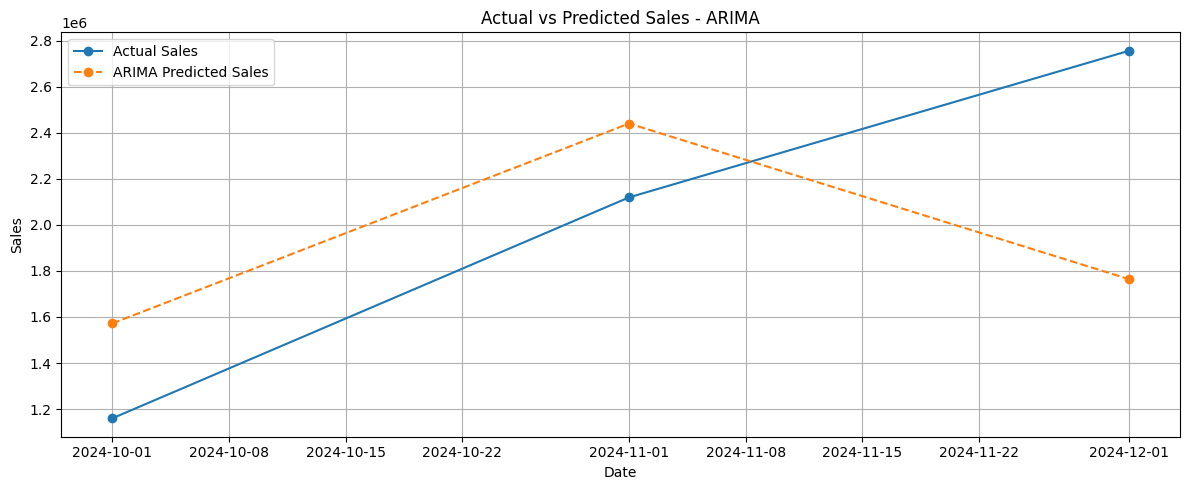

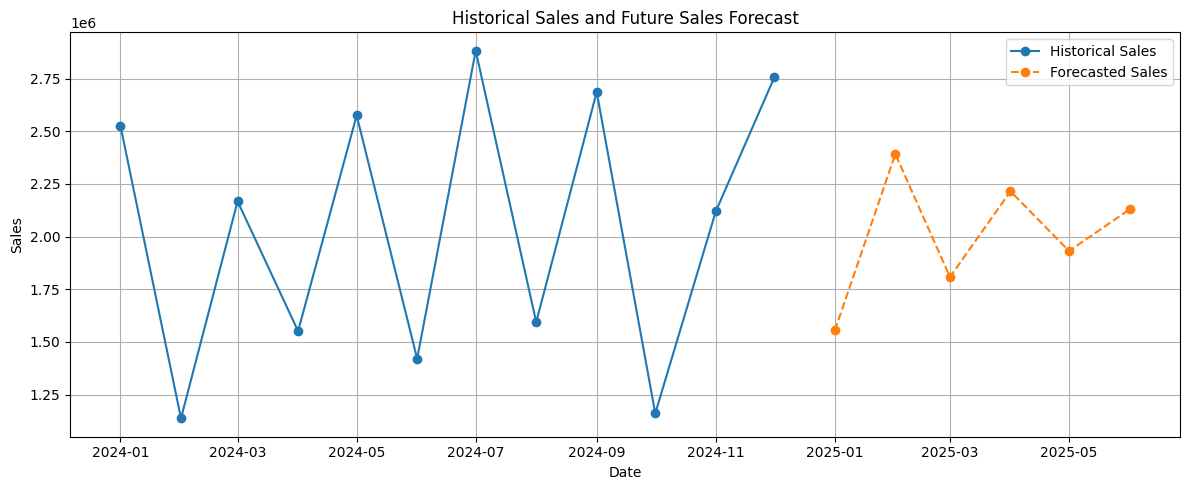

All charts saved successfully!


In [28]:
#Saving the important charts

# Save Monthly Sales Trend
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o"
)
plt.title("Monthly Sales Trend - 2024")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=300)
plt.show()


# Save Actual vs Predicted ARIMA
plt.figure(figsize=(12, 5))
plt.plot(
    test["Date"],
    test["Sales"],
    marker="o",
    label="Actual Sales"
)
plt.plot(
    test["Date"],
    test["ARIMA_Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="ARIMA Predicted Sales"
)
plt.title("Actual vs Predicted Sales - ARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("actual_vs_predicted_arima.png", dpi=300)
plt.show()


# Save Future Forecast
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)
plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)
plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("future_sales_forecast.png", dpi=300)
plt.show()

print("All charts saved successfully!")

# Thiranex Task 3 – Predictive Analytics Using Historical Data

## Project Overview

This project focuses on predictive analytics using historical sales data.
The objective is to analyze historical sales trends, build predictive models,
evaluate their performance, and forecast future sales.

## Dataset

The dataset contains 800 sales records from January 2024 to December 2024.

Key fields include:
- Order Date
- Sales
- Profit
- Quantity
- Product
- Category
- Region
- Customer information

## Data Preprocessing

The dataset was checked for:
- Missing values
- Duplicate records
- Duplicate Order IDs
- Date formatting

No missing values or duplicate records were found.

## Exploratory Data Analysis

Monthly sales were aggregated to identify historical sales trends.
A monthly sales trend visualization was created using Matplotlib.

## Predictive Modeling

Three approaches were explored:

1. Linear Regression
2. Random Forest Regression
3. ARIMA Time-Series Forecasting

ARIMA was selected as the final forecasting approach because it is
specifically designed for time-series data and performed better than
Linear Regression on the test period.

## Model Evaluation

### Linear Regression
- MAE: ₹585,894.91
- RMSE: ₹719,562.62
- R² Score: -0.2033

### ARIMA
- MAE: ₹574,810.32
- RMSE: ₹647,125.05
- R² Score: 0.0268

ARIMA produced lower MAE and RMSE and a positive R² score compared
with the Linear Regression baseline.

## Future Forecast

The final ARIMA model was trained using all 12 months of 2024 historical
sales data and used to forecast sales for January 2025 to June 2025.

## Key Findings

- Sales varied significantly across months.
- July recorded the highest monthly sales in 2024.
- February recorded the lowest monthly sales in 2024.
- ARIMA provided a better test-period performance than the Linear Regression baseline.
- Future sales forecasts show continued monthly variation.

## Conclusion

This project demonstrates the use of historical sales data for predictive
analytics and future trend forecasting. The analysis includes data
preprocessing, exploratory analysis, predictive modeling, model evaluation,
visualization, and future forecasting.

The model results should be interpreted with caution because the dataset
contains only one year of historical monthly observations.